In [34]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.map_handler import MapHandler

from mmwave_radar_processing.config_managers.cfgManager import ConfigManager

from mmwave_model_integrator.encoders.radarhd_encoder import RadarHDEncoder
from mmwave_model_integrator.model_runner.radarhd_runner import RadarHDRunner
from mmwave_model_integrator.decoders.radarhd_decoder import RadarHDDecoder

#load the necessary odometry modules
from odometry.test_benches.radar_model_ekf_tb import RadarModelEKFTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


In [35]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("MODEL_DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
RADARHD_MODEL_STATE_DICT_PATH=os.getenv("RADARHD_MODEL_STATE_DICT_PATH")
CONFIG_DIRECTORY = os.getenv("CONFIG_DIRECTORY")

#setup the datasets
model_dataset_folder_name = "radarHD_comp_datasets"
folder_name = "WILK"
file_name = "WILK_2"

dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,model_dataset_folder_name,folder_name,file_name), #_spin_recall
    radar_folder="radar_0",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

cfg_manager = ConfigManager()
cfg_path = os.path.join(CONFIG_DIRECTORY,"RadarHD.cfg")
cfg_manager.load_cfg(cfg_path)
cfg_manager.compute_radar_perforance(profile_idx=0)

found 1443 radar samples
found 1443 lidar samples
found 1443 camera samples
found 1443 imu (orientation only) samples
found 1443imu (full data) samples
found 1443 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [36]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

In [37]:
#initialize model encoder, runner, and decoder
encoder = RadarHDEncoder(
    config_manager=cfg_manager,
    range_max=10.8,
    num_range_bins=256,
    mag_threshold=0.05,
    num_az_angle_bins=64
)

runner = RadarHDRunner(
    state_dict_path=RADARHD_MODEL_STATE_DICT_PATH,
    cuda_device="cuda:0"
)

decoder = RadarHDDecoder(
    max_range_m=10.8,
    num_range_bins=256,
    num_angle_bins=512
)

_ModelRunner: using GPU: cuda:0


loaded map with 20750 points
loaded map with 20750 points
gt icp estimated heading:-3.5006152954323486 deg, pose:[-0.13953154  0.08213281]
radar icp estimated heading:-3.5006152954323486 deg, pose:[-0.13953154  0.08213281]


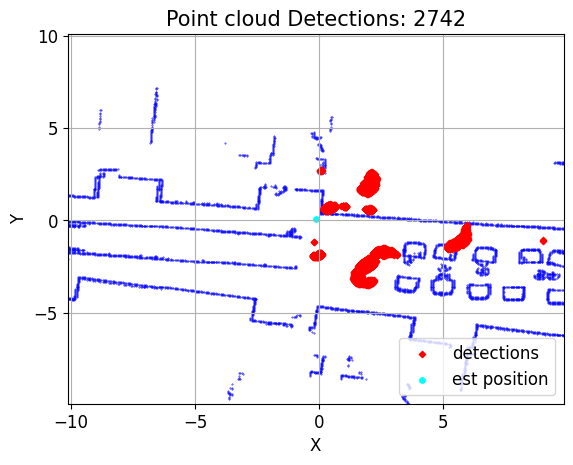

In [38]:
test_bench = RadarModelEKFTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    encoder=encoder,
    runner=runner,
    decoder=decoder
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


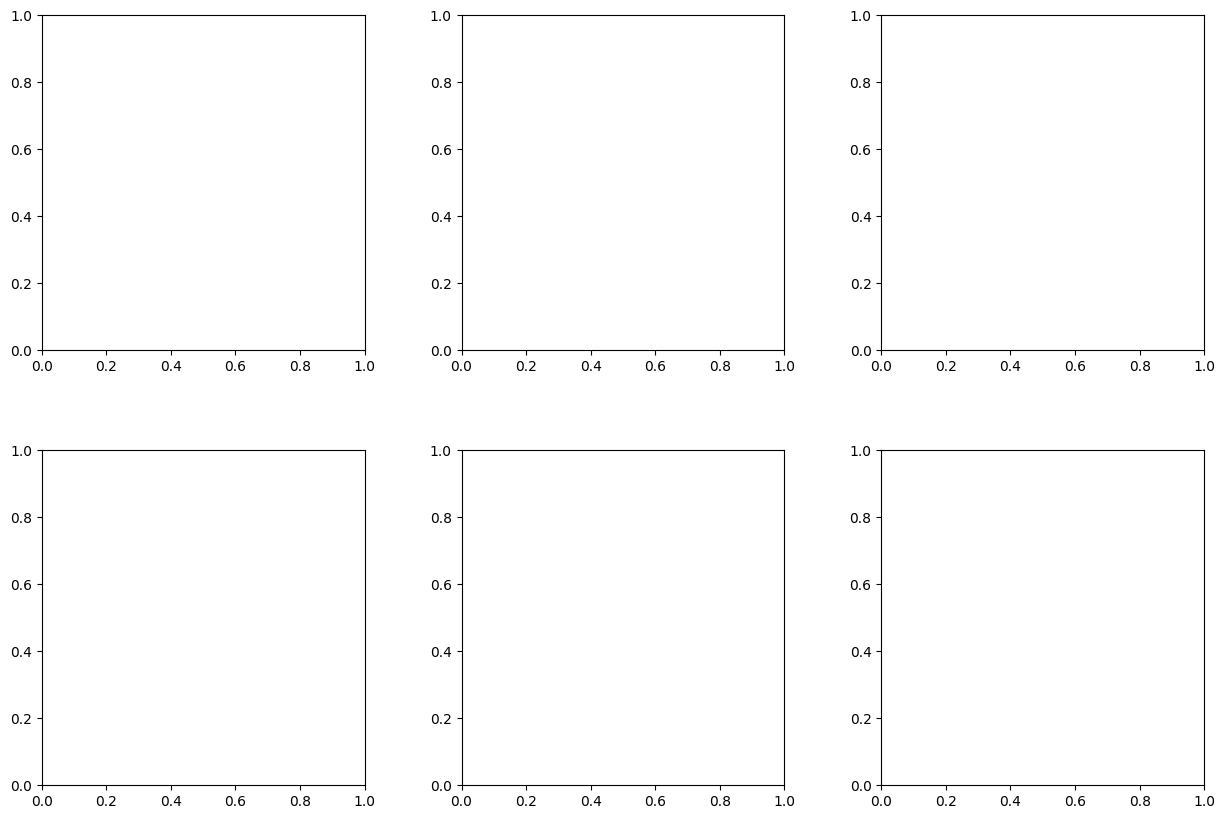

In [39]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [40]:
end_idx = 600 #dataset.num_frames #point cloud sample: frame 740 on WILK_2
save_name = file_name + "_radarhd"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None)

100%|██████████| 600/600 [01:32<00:00,  6.49it/s]


In [ ]:
np.save("Trajectories/gt_radarHD.npy",test_bench.history_position_m_gt)
np.save("Trajectories/radarHD.npy",test_bench.history_position_m)

In [ ]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=10)
#TODO - radar hd should be recording data at 20fps

0it [00:00, ?it/s]


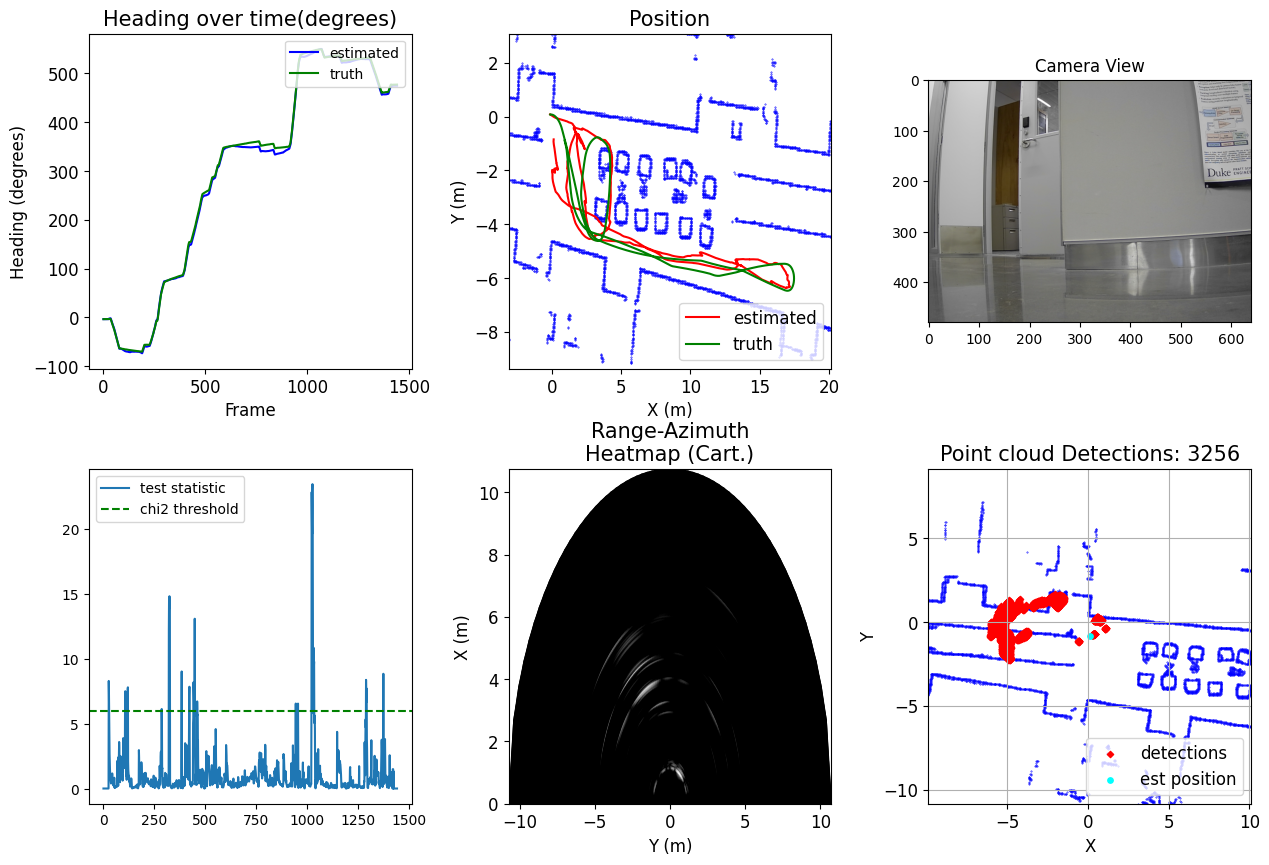

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

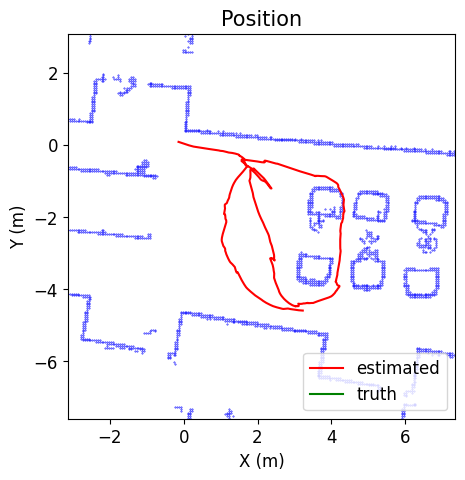

In [41]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

49.668346922546334


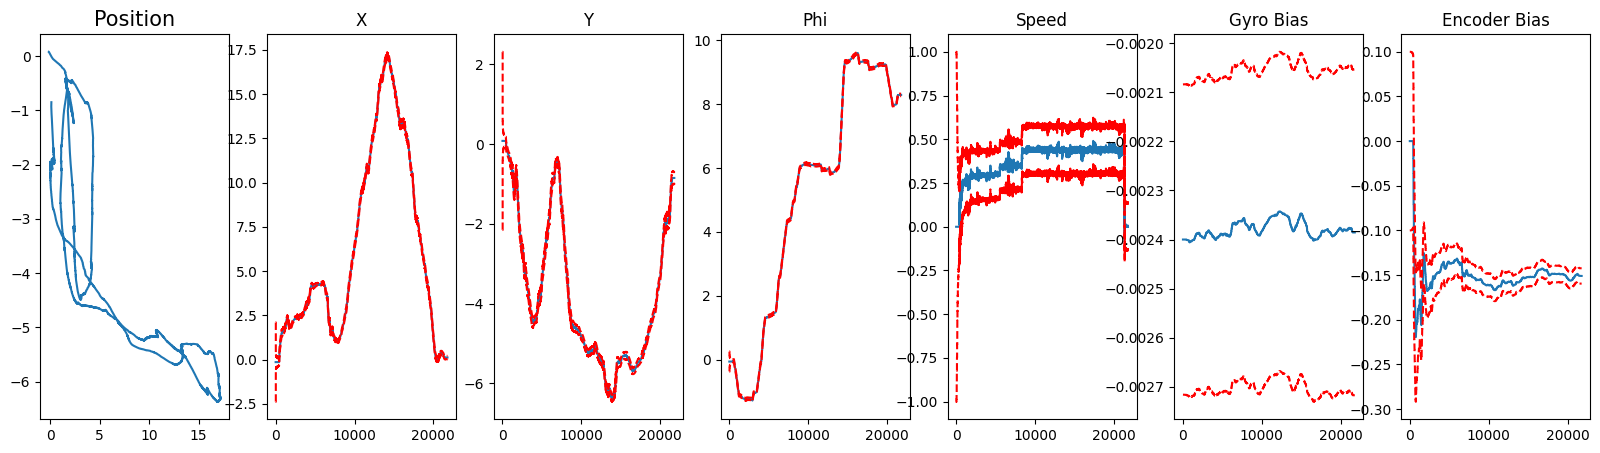

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



bias: 0.13750987083139757 deg/sec, over 1min: 8.250592249883853 deg


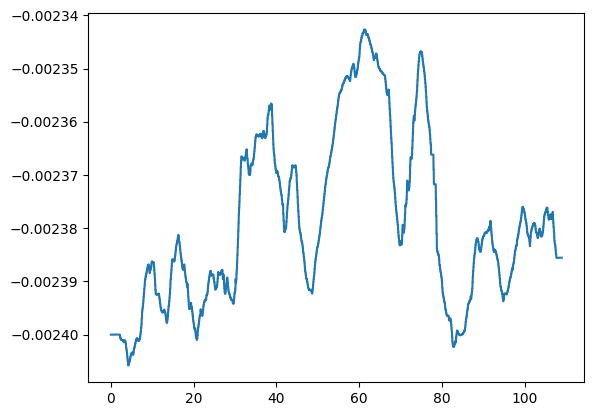

In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


['map', 'detections', 'est position']


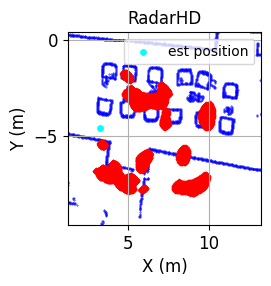

In [43]:
#visualizing the point cloud
fig, axs = plt.subplots(figsize=(2.5,2.5))

pred = test_bench.runner.make_prediction(
    input=test_bench.encoder.encoded_data
)
pc = test_bench.decoder.convert_polar_to_cartesian(
    points_polar=test_bench.decoder.decode(pred)
)

test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,

    show=False
) 
axs.set_title("RadarHD",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 2,
    test_bench.filter.x[0] + 10)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 5,
    test_bench.filter.x[1] + 5)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)

plt.show()

In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

,Metric,Absolute position (m),Relative position (m),Absolute heading (deg),Relative heading (deg)
0,Mean,0.593668,0.022669,3.963718,0.091103
1,stdev,0.433643,0.021650,3.441420,0.079811
2,Median,0.467324,0.015950,3.062754,0.073812
3,0.9th percentile,1.192178,0.048884,10.290139,0.195161


In [ ]:
#timing analysis
for i in tqdm(range(10)):
    encoded_data = test_bench.encoder.encoded_data
    pred = test_bench.runner.make_prediction(encoded_data)
    pc_cart = test_bench.decoder.convert_polar_to_cartesian(
        test_bench.decoder.decode(pred)
    )

100%|██████████| 10/10 [00:00<00:00, 27.71it/s]


loaded map with 20750 points


100%|██████████| 500/500 [00:49<00:00, 10.00it/s]


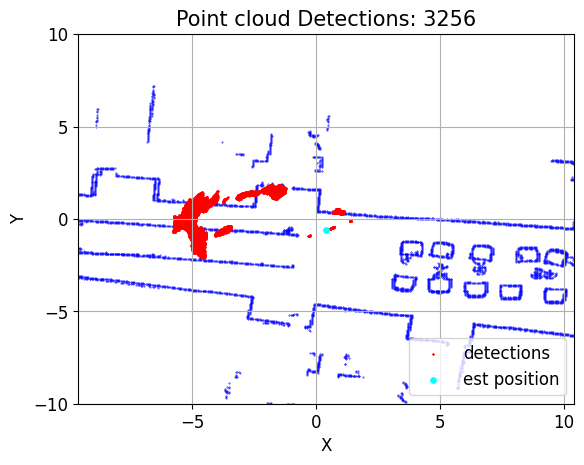

In [ ]:
#testing icp
icp_tb = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

icp_tb.load_map_point_cloud(map_handler.map_points)

#reset the odometry
icp_tb.reset_odometry(
    pose=test_bench.filter.x[0:2],
    heading_rad=test_bench.filter.x[2]
)

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = icp_tb.update_odometry(
        points=pc_cart,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc_cart,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()